# Segmentación K-Means del Comportamiento de Suscriptores con PROC FASTCLUS

## Resumen Ejecutivo

Este notebook segmenta una base sintética de 100 suscriptores móviles en clústeres de comportamiento usando `PROC FASTCLUS`, el procedimiento de agrupamiento k-means de Base SAS. Siete características de uso se estandarizan a puntajes z con `PROC STDIZE` para que las variables de alta magnitud (minutos de voz, cantidad de SMS) no dominen la distancia euclidiana, y luego `PROC FASTCLUS` ajusta tres clústeres. El procedimiento reporta la desviación RMS dentro de clúster, un R-cuadrado general y un pseudo-F que cuantifican qué tan bien la segmentación separa la base (aquí un R-cuadrado general de 0.575 y un pseudo-F de 65.75), y escribe una tabla puntuada con una etiqueta `CLUSTER` en cada suscriptor. Fusionamos esas etiquetas de vuelta con los datos en escala original, perfilamos las personas, y entregamos las asignaciones a la activación posterior.

## Fuentes de Datos

| Conjunto de datos | Descripción | Filas | Variables clave |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Instantánea sintética mensual de comportamiento para una base de suscriptores de telecomunicaciones móviles, generada en línea con `call streaminit` / `rand()`. Tres tipos de comportamiento latentes (datos intensivos, centrado en voz, uso bajo) se mezclan con ruido. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominal), `region` (nominal) |

# Segmentación K-Means del Comportamiento de Suscriptores

**Industria:** Telecomunicaciones &nbsp;|&nbsp; **Procedimiento:** `PROC FASTCLUS` (agrupamiento k-means de Base SAS)

Los operadores móviles tienen suscriptores cuyo comportamiento mensual -- apetito de datos, hábitos de voz, gasto y fricción de soporte -- cae en un puñado de patrones reconocibles. Descubrir esos patrones permite al negocio adaptar los rescates de retención, vender los paquetes adecuados, y adquirir perfiles similares. Este notebook construye una segmentación de comportamiento de principio a fin: genera una instantánea realista de suscriptores, estandariza las características, deja que `PROC FASTCLUS` ajuste los clústeres, puntúa cada suscriptor, y perfila los segmentos en personas accionables. `PROC FASTCLUS` está diseñado exactamente para esta tarea de k-means disjunto y escala a bases muy grandes al recorrer los datos en lugar de construir una matriz de distancia completa.

## 1. Generar una base sintética de suscriptores

Simulamos 100 suscriptores extraídos de tres arquetipos de comportamiento latentes -- **usuarios intensivos de datos**, **tradicionalistas centrados en voz**, y clientes de **uso ligero/bajo** -- y luego mezclamos ruido para que los límites sean difusos (como lo son en la realidad). Cada suscriptor también lleva dos atributos categóricos, `data_plan` y `region`, que usamos más adelante para *perfilar* los segmentos. La semilla hace que los datos sean reproducibles.

In [1]:
/* -----------------------------------------------------------
   Instantánea sintética de suscriptores móviles (100 filas).
   Tres arquetipos de comportamiento latentes + ruido, más dos
   atributos categóricos para el perfilado de segmentos.
   ----------------------------------------------------------- */
DATOS subscribers;
    LLAMAR streaminit(20260531);

    ARREGLO plans[3]   $10 ('Prepago' 'Pospago' 'Ilimitado');
    ARREGLO regions[4] $10 ('Norte' 'Sur' 'Este' 'Oeste');

    HACER subscriber_id = 100001 HASTA 100100;

        /* arquetipo latente: 1=datos intensivos, 2=voz, 3=uso bajo */
        u = rand('uniform');
        SI      u < 0.38 ENTONCES archetype = 1;
        SINO SI u < 0.70 ENTONCES archetype = 2;
        SINO                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        SI archetype = 1 ENTONCES HACER;             /* usuario intensivo de datos */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        END;
        SINO SI archetype = 2 ENTONCES HACER;        /* centrado en voz */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        END;
        SINO HACER;                              /* uso bajo */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        END;

        data_plan = plans[planpick];
        region    = regions[ rand('table', 0.30, 0.28, 0.22, 0.20) ];

        /* redondear a precisión de reporte prolija */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        SALIDA;
    END;

    MANTENER subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
EJECUTAR;



NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Inspeccionar las distribuciones de características

Antes de agrupar, observa la escala y dispersión de cada característica de comportamiento. Las unidades tan distintas -- gigabytes, minutos, dólares, conteos -- son exactamente la razón por la que estandarizamos los insumos de intervalo antes de agrupar; de lo contrario, variables de alta magnitud como `voice_minutes` dominarían la distancia euclidiana que `PROC FASTCLUS` minimiza.

                                                  The MEANS Procedure

 Variable         Label                           N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Antigüedad (Meses)            100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Datos Mensuales (GB)          100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Minutos de Voz                100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Cantidad de SMS               100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     Minutos Internacionales       100  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


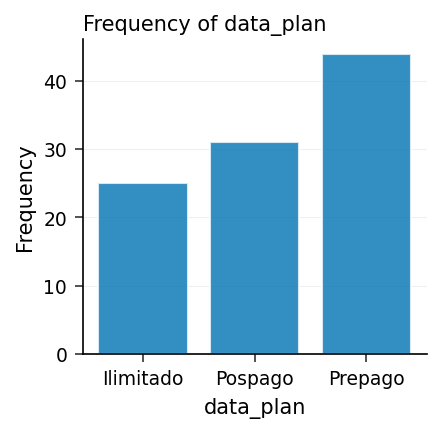

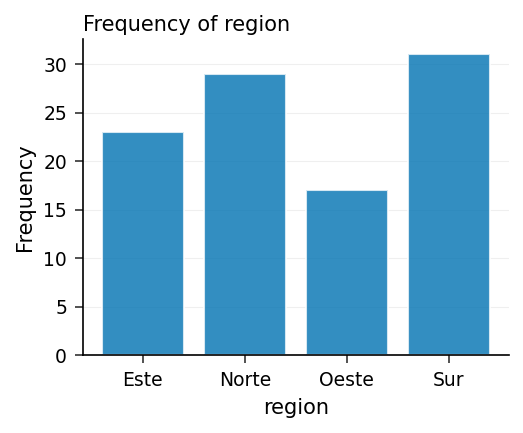

In [2]:
/* Estadísticas resumen para los insumos de agrupamiento */
PROCEDIMIENTO MEDIAS DATOS=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETIQUETA tenure_months='Antigüedad (Meses)' monthly_data_gb='Datos Mensuales (GB)'
          voice_minutes='Minutos de Voz' sms_count='Cantidad de SMS'
          intl_minutes='Minutos Internacionales' arpu='ARPU' support_calls='Llamadas de Soporte';
EJECUTAR;

/* Frecuencia de los dos insumos categóricos */
PROCEDIMIENTO FRECUENCIAS DATOS=subscribers;
    TABLES data_plan region / nocum;
    ETIQUETA data_plan='Plan de Datos' region='Región';
EJECUTAR;


## 3. Estandarizar las características a puntajes z

`PROC FASTCLUS` minimiza la distancia euclidiana, así que una variable medida en cientos de minutos abrumaría a una medida en gigabytes de un solo dígito. `PROC STDIZE` con `METHOD=STD` reescala cada característica de intervalo a media 0 y desviación estándar 1, dando a cada comportamiento el mismo peso en la distancia. Las columnas categóricas y el identificador pasan sin cambios para que podamos perfilar los clústeres en su escala original después.

In [3]:
/* estandarizar a puntajes z las características de intervalo; los ids y categóricos pasan sin cambios */
PROCEDIMIENTO stdize DATOS=subscribers out=subs_std METHOD=std;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
EJECUTAR;



NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Ajustar la segmentación k-means

Ajustamos tres segmentos con `PROC FASTCLUS`. `MAXCLUSTERS=3` fija *k*; `MAXITER=20` permite que los centros de clúster iteren hasta converger. El procedimiento reporta un **Resumen de Clúster** (tamaño y desviación RMS dentro de clúster por clúster), **Estadísticas para Variables** (el R-cuadrado que aporta cada característica), un **R-cuadrado general** y **pseudo-F** que miden qué tan limpiamente los tres clústeres separan la base, y **Medias de Clúster** en la escala estandarizada. `OUT=scored` escribe las filas de entrada de vuelta con una etiqueta `CLUSTER` y la `DISTANCE` de cada suscriptor a la semilla de su clúster.

In [4]:
/* ajuste k-means sobre las características estandarizadas: 3 segmentos. */
PROCEDIMIENTO FASTCLUS DATOS=subs_std maxclusters=3 MAXITER=20 out=scored;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETIQUETA tenure_months='Antigüedad (Meses)' monthly_data_gb='Datos Mensuales (GB)'
          voice_minutes='Minutos de Voz' sms_count='Cantidad de SMS'
          intl_minutes='Minutos Internacionales' arpu='ARPU' support_calls='Llamadas de Soporte';
EJECUTAR;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Adjuntar etiquetas de segmento a los datos en escala original

La tabla puntuada guarda las características estandarizadas; para perfilar queremos que los clústeres se describan en gigabytes, minutos y dólares reales. Fusionamos la etiqueta `CLUSTER` de vuelta a la tabla original `subscribers` por `subscriber_id`, y luego hacemos la primera pregunta que marketing siempre hace: *¿qué tan grande es cada segmento?*

                                                   The FREQ Procedure

Segmento    Frequency    Percent
---------------------------------
1                  36     36.00
2                  34     34.00
3                  30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


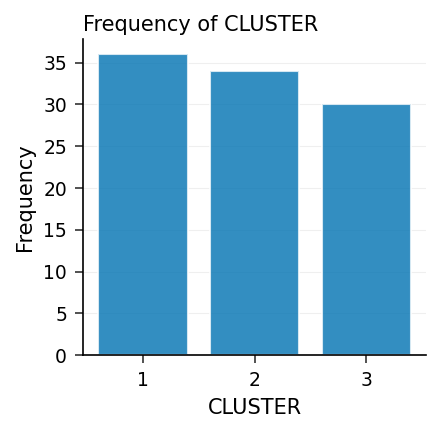

In [5]:
/* llevar la etiqueta de clúster de vuelta a los datos en escala original */
PROCEDIMIENTO ORDENAR DATOS=scored(MANTENER=subscriber_id CLUSTER distance) out=clus_assign;
    POR subscriber_id;
EJECUTAR;
PROCEDIMIENTO ORDENAR DATOS=subscribers out=subs_sorted;
    POR subscriber_id;
EJECUTAR;
DATOS profile;
    COMBINAR subs_sorted clus_assign;
    POR subscriber_id;
EJECUTAR;

/* ¿Cuántos suscriptores cayeron en cada segmento? */
PROCEDIMIENTO FRECUENCIAS DATOS=profile;
    TABLES CLUSTER / nocum;
    ETIQUETA CLUSTER='Segmento';
EJECUTAR;


## 6. Perfilar los segmentos

Los ID de clúster no tienen sentido hasta que describimos el *comportamiento* dentro de cada uno. Promediar las características originales (no estandarizadas) por `CLUSTER` revela la persona detrás de cada segmento -- quién transmite, quién habla, quién apenas usa la red -- y la mezcla categórica muestra qué planes y regiones se concentran en cada uno.

                                                  The MEANS Procedure

                                 Analysis Variable : tenure_months Antigüedad (Meses)

        Segmento          N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                                Analysis Variable : monthly_data_gb Datos Mensuales (GB)

        Segmento          N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                    Analysis Variable : voice_minutes Minutos de Voz

        Segmento          N Obs           Mean
        --------------------------------------
      


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


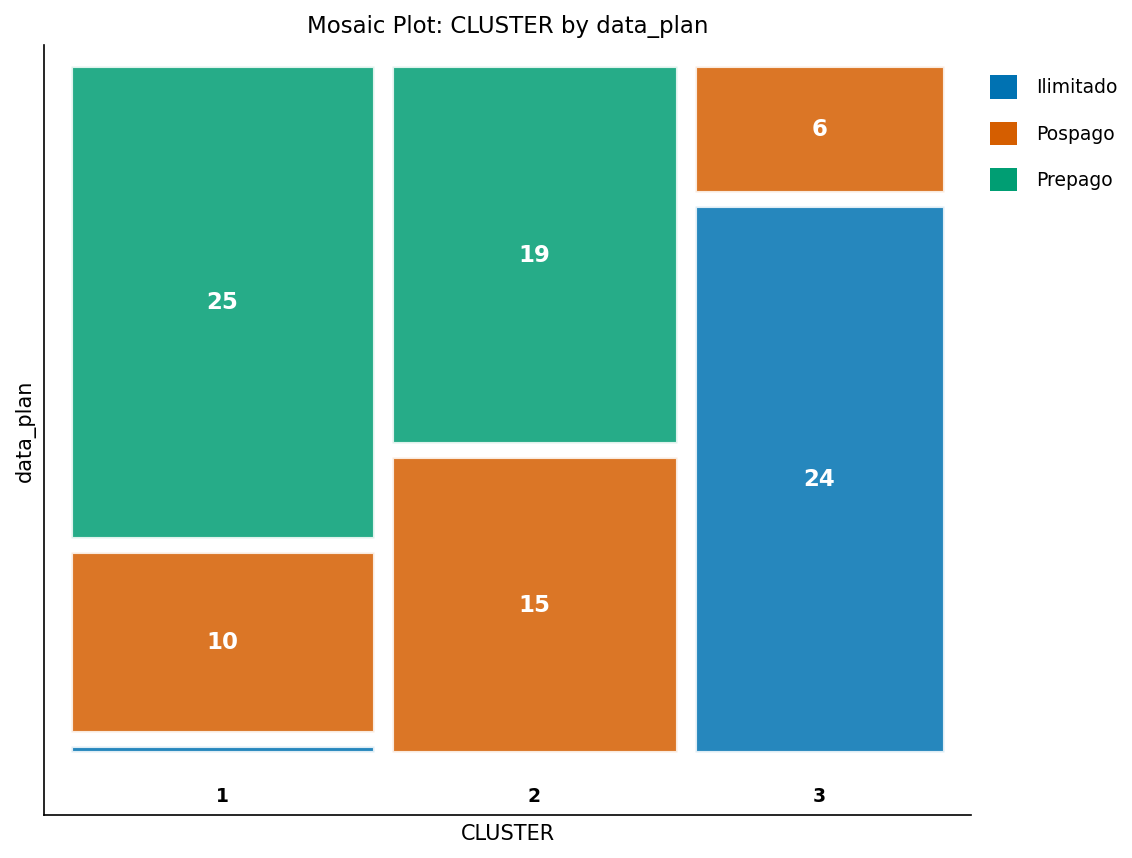

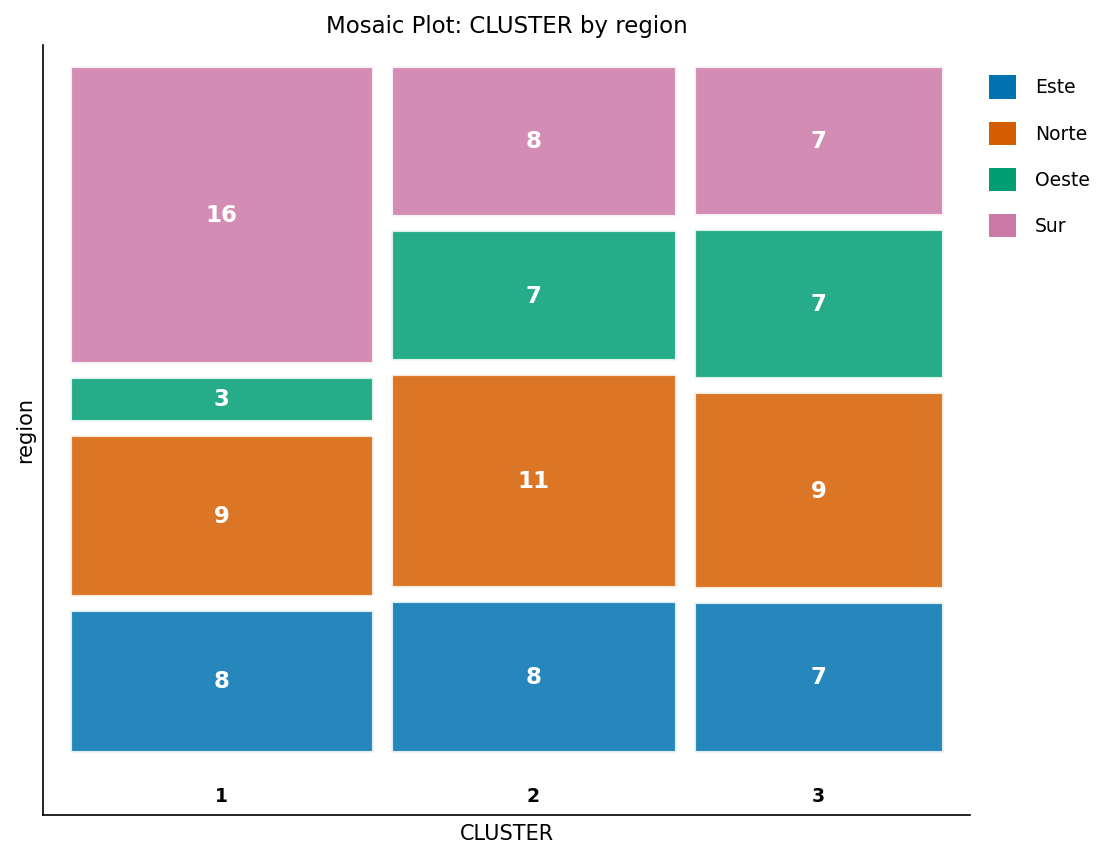

In [6]:
/* Perfil de comportamiento: media de cada característica por segmento */
PROCEDIMIENTO MEDIAS DATOS=profile n mean maxdec=1;
    CLASE CLUSTER;
    VAR tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
    ETIQUETA CLUSTER='Segmento' tenure_months='Antigüedad (Meses)' monthly_data_gb='Datos Mensuales (GB)'
          voice_minutes='Minutos de Voz' sms_count='Cantidad de SMS'
          intl_minutes='Minutos Internacionales' arpu='ARPU' support_calls='Llamadas de Soporte';
EJECUTAR;

/* Mezcla categórica dentro de cada segmento */
PROCEDIMIENTO FRECUENCIAS DATOS=profile;
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
    ETIQUETA CLUSTER='Segmento' data_plan='Plan de Datos' region='Región';
EJECUTAR;


## 7. Visualizar los segmentos

Una imagen hace tangible la segmentación. Graficamos el apetito de datos contra el uso de voz, coloreado por segmento, y añadimos un diagrama de caja de ARPU por segmento para que la historia de ingresos sea obvia de un vistazo.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


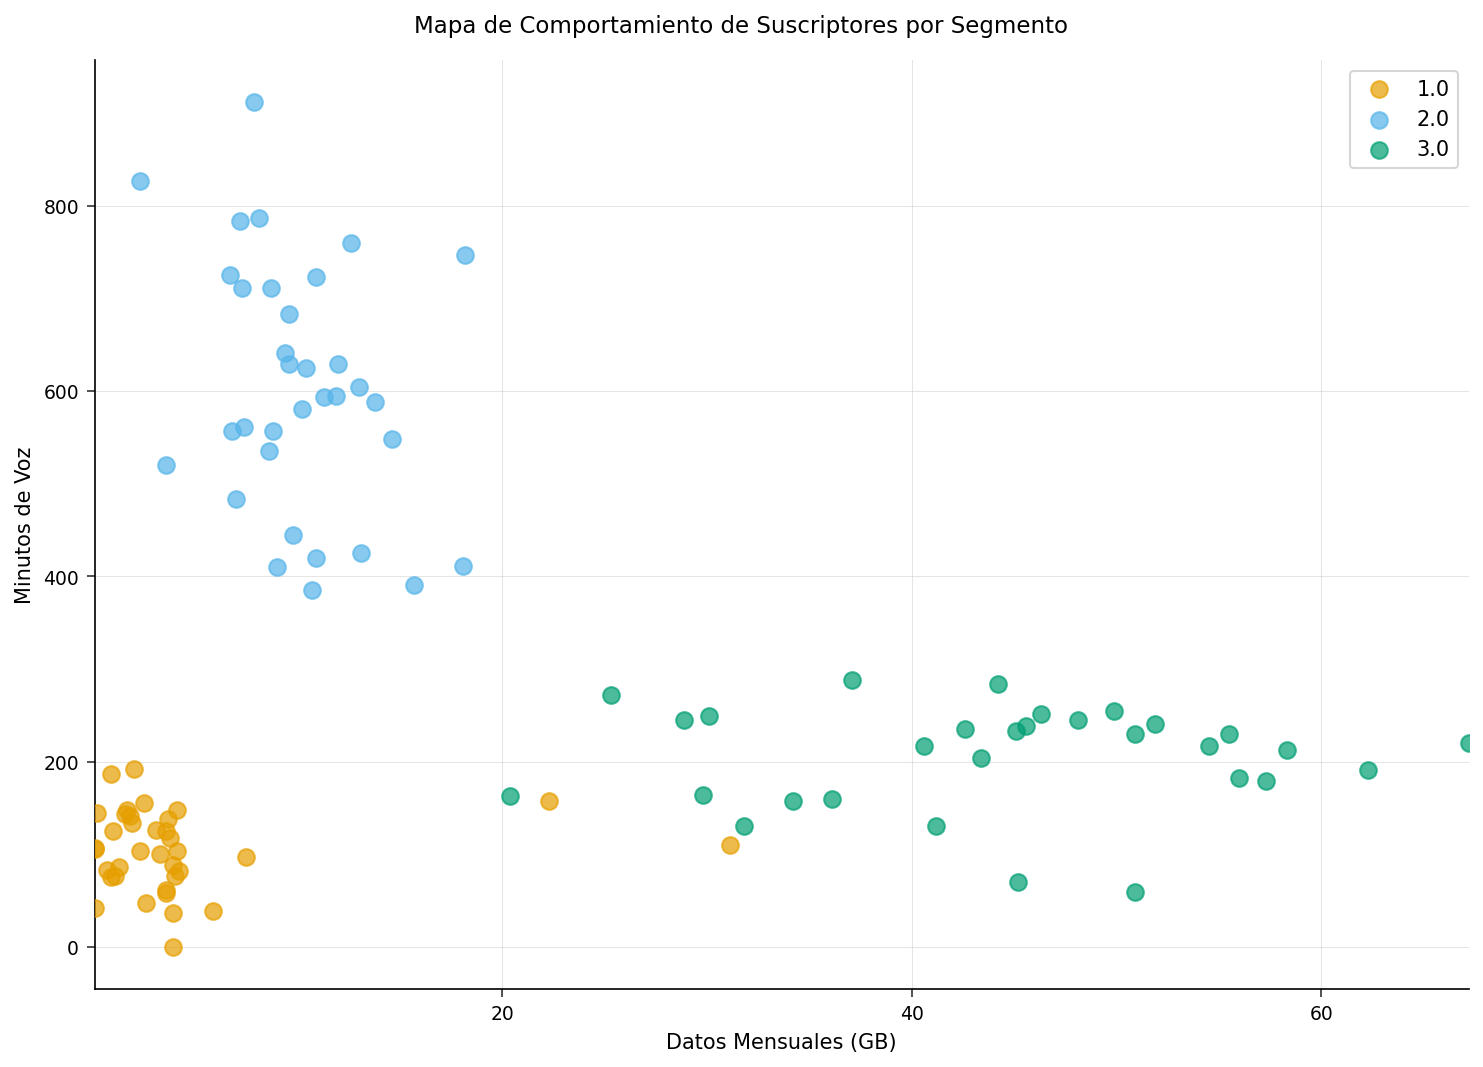

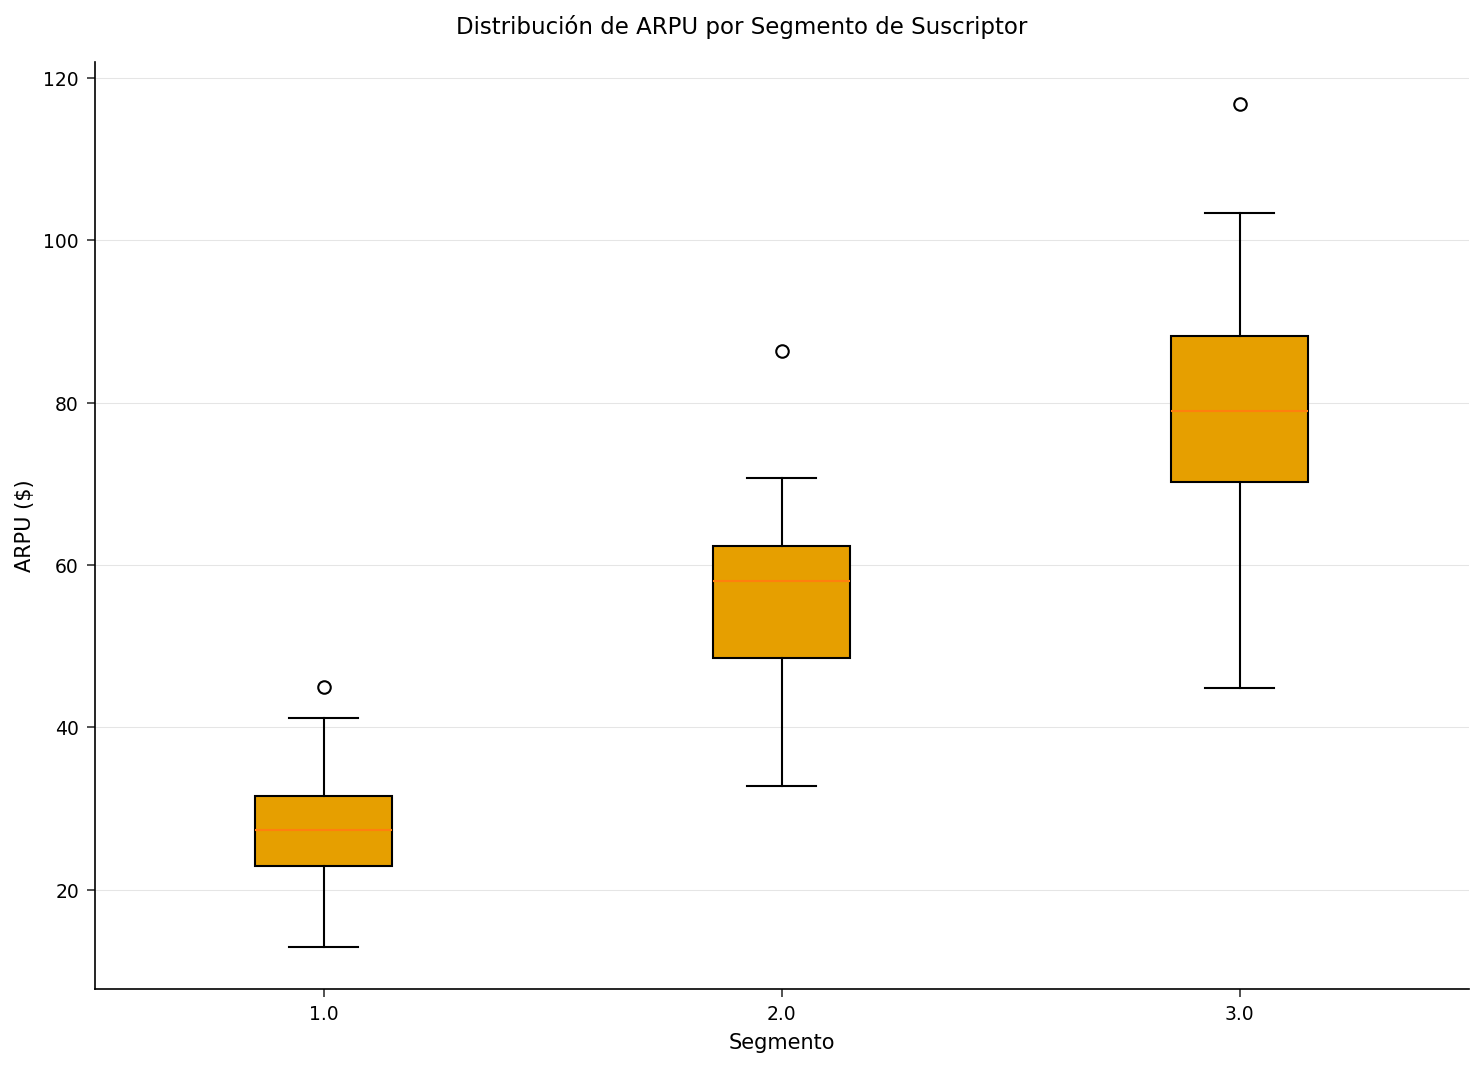

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Mapa de comportamiento: datos vs. voz, coloreado por segmento */
PROCEDIMIENTO SGPLOT DATOS=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS LABEL='Datos Mensuales (GB)' grid;
    YAXIS LABEL='Minutos de Voz'     grid;
    TÍTULO 'Mapa de Comportamiento de Suscriptores por Segmento';
EJECUTAR;

/* Distribución de ingresos por segmento */
PROCEDIMIENTO SGPLOT DATOS=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS LABEL='Segmento';
    YAXIS LABEL='ARPU ($)' grid;
    TÍTULO 'Distribución de ARPU por Segmento de Suscriptor';
EJECUTAR;


## 8. Exportar los segmentos puntuados

Finalmente, entregamos las asignaciones a los sistemas de CRM y campañas posteriores. Mantenemos el identificador, la etiqueta de clúster, y los campos de comportamiento principales.

In [8]:
/* Persistir las asignaciones de segmento para activación */
DATOS subscriber_segments;
    ESTABLECER profile;
    MANTENER subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=subscriber_segments(obs=10) noobs;
    TÍTULO 'Muestra de Segmentos de Suscriptores Clasificados';
    ETIQUETA subscriber_id='ID de Suscriptor' CLUSTER='Segmento' tenure_months='Antigüedad (Meses)'
          monthly_data_gb='Datos Mensuales (GB)' voice_minutes='Minutos de Voz' arpu='ARPU'
          data_plan='Plan de Datos' region='Región';
EJECUTAR;


                                   Muestra de Segmentos de Suscriptores Clasificados                                    

ID de Suscriptor  Segmento   Antigüedad (Meses)  Datos Mensuales (GB)  Minutos de Voz   ARPU  Plan de Datos   Región
          100001         1                   30                   2.3             104     28  Prepago        Sur
          100002         2                    8                  10.2             581  57.78  Prepago        Oeste
          100003         2                    8                  10.7             385  55.66  Pospago        Norte
          100004         2                   68                   7.4             561  70.68  Prepago        Norte
          100005         3                   18                  45.6             239  63.85  Ilimitado      Norte
          100006         3                   10                  30.1             249  88.33  Ilimitado      Este
          100007         1                   62                   0.7     


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Interpretando los resultados

`PROC FASTCLUS` recuperó tres segmentos limpios y bien separados. El ajuste es sólido: el **R-cuadrado general es 0.575** y el **pseudo-F es 65.75**, lo que significa que los tres clústeres explican aproximadamente el 58% de la variación total en las características estandarizadas. La separación está impulsada casi por completo por las señales de comportamiento que nos importan -- `voice_minutes` (R-cuadrado 0.858), `monthly_data_gb` (0.844), y `arpu` (0.771) llevan la segmentación, mientras que `tenure_months` (0.000) y `support_calls` (0.193) contribuyen casi nada, confirmando que *cómo* un suscriptor usa la red -- no cuánto tiempo ha sido cliente -- define las personas.

Los tres segmentos se mapean directamente a personas listas para marketing, perfiladas aquí en la escala original (no estandarizada):

| Segmento | n (participación) | Comportamiento distintivo | Mezcla de planes | Persona | Jugada recomendada |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | Mayor uso de datos: **44.4 GB/mes**, mayor gasto **$79.1 ARPU**, voz modesta (205 min) | 24/30 **Ilimitado** | **Usuarios intensivos de datos** | Proteger y vender más: niveles más rápidos, paquetes de contenido, mejoras de dispositivo |
| **2** | 34 (34%) | Mayor voz **603 min/mes**, **214 SMS**, **106 min. intl.**, gasto medio **$55.9 ARPU** | Prepago + Pospago, **sin Ilimitado** | **Tradicionalistas centrados en voz** | Complementos internacionales, paquetes familiares/de voz, recompensas de lealtad |
| **1** | 36 (36%) | Menor uso: **4.0 GB**, 104 min de voz, menor gasto **$28.0 ARPU** | 25/36 **Prepago** | **Uso ligero/bajo** | Ajustar planes al tamaño adecuado, incentivos de pago automático, iniciadores de datos de bajo costo para aumentar el uso |

La mezcla de planes corrobora la lectura de comportamiento: el segmento de datos intensivos está abrumadoramente en planes **Ilimitado** (24 de 30), el segmento centrado en voz no tiene **ningún** suscriptor Ilimitado, y el segmento de uso ligero es mayormente **Prepago** (25 de 36). La región, en cambio, se distribuye de manera uniforme entre los tres segmentos -- la geografía no es un factor de comportamiento aquí, lo cual es en sí un hallazgo útil para la segmentación de campañas.

**Por qué `PROC FASTCLUS` se ajusta a este problema.** Ejecuta k-means disjunto al recorrer los datos en lugar de materializar una matriz de distancia completa, así que el mismo programa que segmentó a estos 100 suscriptores escala a bases muy grandes. Estandarizar primero con `PROC STDIZE` eliminó el sesgo de escala de unidades entre gigabytes, minutos y dólares, de modo que cada comportamiento contribuyó por igual a la distancia euclidiana; los diagnósticos de R-cuadrado luego nos dijeron *qué* características realmente impulsaron la división. La salida puntuada -- una etiqueta `CLUSTER` en cada suscriptor -- se conecta directamente a los pipelines de activación, cerrando el ciclo desde el comportamiento crudo hasta la oferta dirigida.

---

<div style="font-size:11px;color:#9e9e9e">Este notebook se proporciona únicamente con fines de demostración. Los datos son sintéticos y los hallazgos no constituyen asesoramiento empresarial.</div>